# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

O conjunto de dados consiste em vetores de características pertencentes a 12.330 sessões.
O conjunto de dados foi formado de modo que cada sessão
pertencesse a um usuário diferente em um período de 1 ano para evitar
qualquer tendência a uma campanha específica, dia especial, perfil de usuário ou período.

## <font color='green'>Preparação</font>

In [21]:
!pip install pandas scikit-learn ucimlrepo

In [22]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Quando usamos o escalonamento para o dataset inteiro estamos ele injeta informações para a IA com o intuito de de transformar o conjunto de treino. Por causa dessa injeção ela fica sabendo de informações que ela não deveria saber, resultando em métricas falsas.  

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    _X_uci, _y_uci,
    test_size=0.2,
    random_state=22
)
print(X_train.shape)
print(X_test.shape)

(9864, 17)
(2466, 17)


## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [24]:
categoricas = X_train.select_dtypes(include=['object']).columns
print(list(categoricas))

['Month', 'VisitorType']


### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [25]:
from numpy import random
coluna_nominal = X_train["Browser"]
amostras = coluna_nominal.sample(n=10, random_state=22)
print(amostras)

11318    2
7774     2
1977     2
6967     2
8389     1
2785     5
2636     5
5568     2
5551     1
9886     2
Name: Browser, dtype: int64


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [26]:
from sklearn.preprocessing import OneHotEncoder
encodin = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
visitor_encodin = encodin.fit_transform(X_train[["VisitorType"]])
print(visitor_encodin)

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [27]:
df_transformado = pd.DataFrame(
    visitor_encodin,
    columns=encodin.get_feature_names_out(['VisitorType']),
    index=X_train.index
)

print(df_transformado.sample(n=10, random_state=22))

#Conseguimos perceber que quando implementamos a tecnica one-Hot-Encodin vamos que os dados de texte foram convertidos em numeros binarios sem criar hierarquia false entre eles.

       VisitorType_New_Visitor  VisitorType_Other  \
11318                      0.0                0.0   
7774                       0.0                0.0   
1977                       0.0                0.0   
6967                       1.0                0.0   
8389                       0.0                0.0   
2785                       0.0                0.0   
2636                       0.0                0.0   
5568                       0.0                0.0   
5551                       0.0                0.0   
9886                       0.0                0.0   

       VisitorType_Returning_Visitor  
11318                            1.0  
7774                             1.0  
1977                             1.0  
6967                             0.0  
8389                             1.0  
2785                             1.0  
2636                             1.0  
5568                             1.0  
5551                             1.0  
9886                      

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Porque algoritimos como KNN desconsideram os dados que não esão com a mesma proporção, quando ele descarta ele pega o maior valor para fazer os calculos.

### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

In [28]:
BounceRates=X_train['BounceRates']
print(BounceRates)

5252     0.003448
11808    0.023333
351      0.020000
892      0.016000
8146     0.013333
           ...   
6646     0.000000
5478     0.043750
8548     0.007701
6276     0.000000
11125    0.004138
Name: BounceRates, Length: 9864, dtype: float64


### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [29]:
BounceRates.describe()

media = BounceRates.mean()
mediana = BounceRates.median()
desvio_padrao = BounceRates.std()
minimo = BounceRates.min()
maximo = BounceRates.max()

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")


Média: 0.02
Mediana: 0.00
Desvio Padrão: 0.05
Mínimo: 0.00
Máximo: 0.20


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

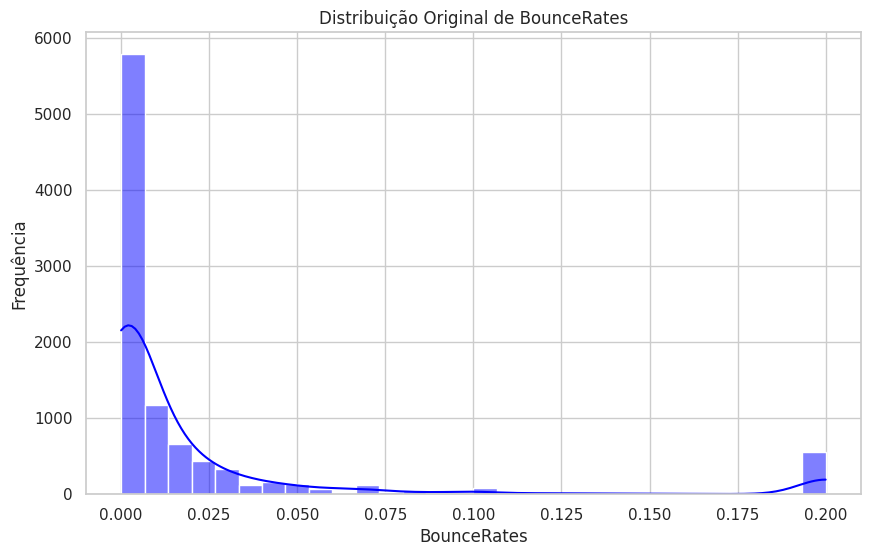

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(BounceRates, kde=True, color="Blue", bins=30)

plt.title("Distribuição Original de BounceRates")
plt.xlabel("BounceRates")
plt.ylabel("Frequência")

plt.show()


### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train['BounceRates'] = scaler.fit_transform(X_train[['BounceRates']])
X_test['BounceRates'] = scaler.transform(X_test[['BounceRates']])

print(X_train['BounceRates'])
print(X_test['BounceRates'])

5252    -0.386623
11808    0.023853
351     -0.044955
892     -0.127525
8146    -0.182571
           ...   
6646    -0.457804
5478     0.445303
8548    -0.298831
6276    -0.457804
11125   -0.372387
Name: BounceRates, Length: 9864, dtype: float64
593    -0.457804
9442   -0.457804
6793   -0.279528
5147    3.670683
710    -0.457804
          ...   
5512    0.153824
4621   -0.349159
3685   -0.292664
1741    0.918359
450     0.367894
Name: BounceRates, Length: 2466, dtype: float64


### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [32]:
bounce_rates=X_train['BounceRates']
bounce_rates.describe()

# ou

media = bounce_rates.mean()
mediana = bounce_rates.median()
desvio_padrao = bounce_rates.std()
minimo = bounce_rates.min()
maximo = bounce_rates.max()

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")


Média: 0.00
Mediana: -0.39
Desvio Padrão: 1.00
Mínimo: -0.46
Máximo: 3.67


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

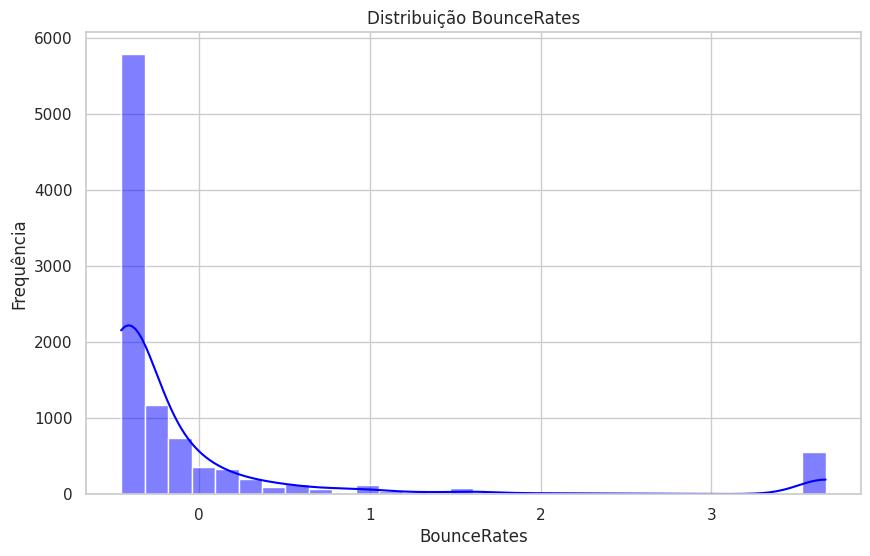

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(bounce_rates, kde=True, color="Blue", bins=30)

plt.title("Distribuição BounceRates")
plt.xlabel("BounceRates")
plt.ylabel("Frequência")

plt.show()


### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

Antes:
* Média: 0.02
* Mediana: 0.00
* Desvio Padrão: 0.05
* Mínimo: 0.00
* Máximo: 0.20
---
Depois:
* Média: 0.00
* Mediana: -0.39
* Desvio Padrão: 1.00
* Mínimo: -0.46
* Máximo: 3.67
---
Média e Desvio padronizou as variações.

Mínimo e Máximo deixaram de ser taxas fixas e passaram a indicar a distância da média.

Eixo X mudou de valores espremidos para uma escala de unidades de desvio.

A Curva continua a mesma.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [34]:
total_abandon = X_train['BounceRates'] + X_train['ExitRates']
X_train['Total_Abandon'] = total_abandon

print(X_train['Total_Abandon'])

# A logica da minha nova variavel é fazer a soma dos valores das colunas BounceRates e ExitRates e criar uma nota tabela com esses valores.

5252    -0.361105
11808    0.055520
351     -0.004955
892     -0.095525
8146    -0.133904
           ...   
6646    -0.449108
5478     0.524470
8548    -0.276445
6276    -0.450396
11125   -0.360775
Name: Total_Abandon, Length: 9864, dtype: float64


### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [35]:
from numpy import random
colun_total_abandon = X_train["Total_Abandon"]
amostras = colun_total_abandon.sample(n=10, random_state=22)
print(amostras)

11318   -0.439504
7774    -0.435581
1977    -0.420304
6967    -0.450827
8389    -0.323443
2785    -0.077096
2636     0.199327
5568     2.461188
5551    -0.391137
9886     0.427894
Name: Total_Abandon, dtype: float64


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [36]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()

train_num = pd.Series(le.fit_transform(y_train), index=X_train.index)

correlacao = X_train['Total_Abandon'].corr(train_num)

print(f"A correlaçao é: {correlacao:.2f}")

# A correlação foi negativa; Fraca
# Por ser uma correlação negativa e fraca ela potencialmente não ajudara um modelo ML.

A correlaçao é: -0.15


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

A principal diferença conceitual entre Extrção de atributos e Seleção de Atributos sao como os dados são tratados em cada uma delas. A seleção de atributos filtra os dados não alterando nenhum dado original. Já a Extração de Atributos ele cria stributos novos atraves da combinação das colunas originais.

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

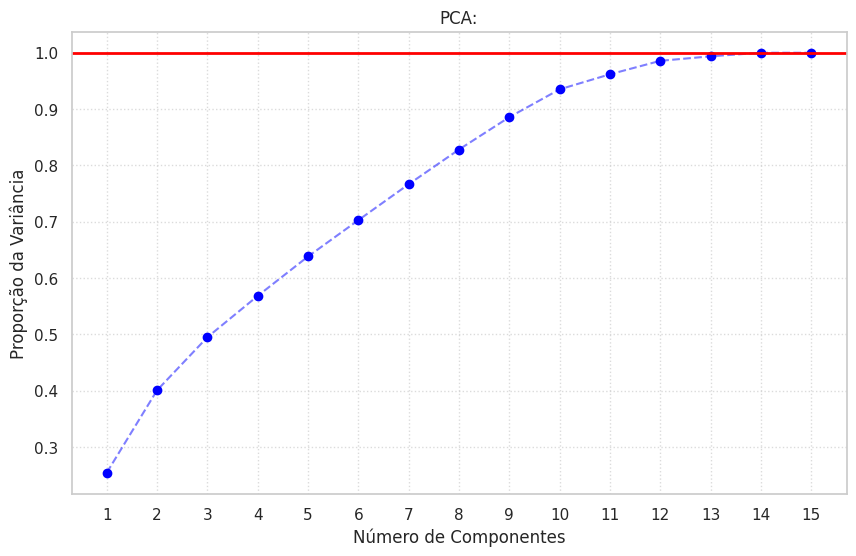

In [51]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

X_train_numerico = X_train.select_dtypes(include=['number'])

scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_numerico)

pca = PCA()
pca.fit(X_train_scaled)

variancia_cumulativa = np.cumsum(pca.explained_variance_ratio_)
numero_componentes = np.arange(1, len(variancia_cumulativa) + 1)

plt.figure(figsize=(10, 6))
plt.scatter(numero_componentes, variancia_cumulativa, color='blue')
plt.plot(numero_componentes, variancia_cumulativa, color='blue', linestyle='--', alpha=0.5)

plt.axhline(y=0.999, color='red', linestyle='-', linewidth=2)

plt.title('PCA:')
plt.xlabel('Número de Componentes')
plt.ylabel('Proporção da Variância')
plt.xticks(numero_componentes)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


#C) A Quantidade minima de componentes para atingir os 99.9% são 14. Usamos um limiar alto para garantir que nenhuma informação relevante original seja descartada na transformação.

### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [53]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

X_test['Total_Abandon'] = X_test['BounceRates'] + X_test['ExitRates']
X_test_numerico = X_test.select_dtypes(include=['number'])
X_test_scaled = scaler_pca.transform(X_test_numerico)

pca_final = PCA(n_components=0.999)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(" ANTES do PCA")
print(f"Treino: {X_train_scaled.shape}")
print(f"Teste:  {X_test_scaled.shape}\n")

print("DEPOIS do PCA")
print(f"Treino: {X_train_pca.shape}")
print(f"Teste:  {X_test_pca.shape}\n")

pesos_pc1 = pca_final.components_[0]
importancias_pc1 = pd.Series(np.abs(pesos_pc1), index=X_train_numerico.columns)
top_3_atributos = importancias_pc1.sort_values(ascending=False).head(3)

print("3 atributos que mais influenciam a PC1")
print(top_3_atributos)

 ANTES do PCA
Treino: (9864, 15)
Teste:  (2466, 15)

DEPOIS do PCA
Treino: (9864, 14)
Teste:  (2466, 14)

3 atributos que mais influenciam a PC1
ExitRates        0.406775
Total_Abandon    0.383236
BounceRates      0.380552
dtype: float64
